In [4]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import time
import hashlib

username = "muskan.sharma"
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)


1.1 Image Pre-Processing

In [3]:
def preprocess_images(bg_path, test_path, target_size=(200, 300)):
    
    try:
        bg_image = Image.open(bg_path).resize(target_size)
        test_image = Image.open(test_path).resize(target_size)
    except Exception as e:
        print(f"Error loading images: {e}")
        return None, None
    
    # (H,W,3) format
    bg_np = np.array(bg_image).astype(np.float32)
    test_np = np.array(test_image).astype(np.float32)

    H, W, D = bg_np.shape

    # Feature extraction (RGB Channel)
    bg_features = bg_np.reshape(-1, D)
    test_features = test_np.reshape(-1, D)

    return bg_features, test_features, bg_np, test_np


BG_FILE = 'back.jpg'
TEST_FILE = 'Full.jpg'
TARGET_SIZE = (200, 300) 

bg_features, test_features, bg_array, test_array = preprocess_images(BG_FILE, TEST_FILE, TARGET_SIZE)
print("Background Features Shape:", bg_features.shape)
print("Test Features Shape:", test_features.shape)


Background Features Shape: (60000, 3)
Test Features Shape: (60000, 3)


Chosen Approach:

Image Alignment and Resizing: Both the background and test images are resized to a common dimension of (200, 300) (Height, Width).

Feature Extraction: The RGB color channels are extracted, resulting in a 3-dimensional feature vector ($D=3$) for each pixel. The images are reshaped from $(H, W, 3)$ to $(N, 3)$, where $N = H \times W$.

Justification for Chosen Approach and Feature Representation:

Computational Efficiency vs. Quality: Resizing the images to (200, 300) significantly reduces the number of samples (pixels) from potentially millions to $N = 60,000$. This is crucial because the KDE prediction step has a complexity of $O(M \cdot n \cdot D)$, where $M$ is the number of test samples and $n$ is the number of training samples. Reducing $N$ to $60,000$ (and then sampling it further down to $n=6,000$ in the fit method) makes the process computationally feasible while retaining enough detail for foreground detection.

Feature Choice (RGB): RGB color channels are a robust and highly relevant feature for this task. Foreground detection relies on identifying pixels with a color signature that is statistically improbable to belong to the background model. Since the background image is assumed to be stationary, its color distribution is stable. KDE performs optimally with low-dimensional data (here, $D=3$). Using RGB allows the model to effectively learn the density distribution of background colors, enabling accurate anomaly (foreground) detection when a new, distinct color appears.

In [9]:

class KDE:
    def __init__(self, bandwidth=1.0, kernel="gaussian", data=None):
        self.bandwidth = float(bandwidth)
        self.kernel = kernel
        self.data = data

    def fit(self, data, sample_frac=0.1):
        
        if data.ndim == 1:
            data = data.reshape(-1, 1)
        elif data.ndim != 2:
            data = data.reshape(-1, data.shape[-1])
        
        n_total = data.shape[0]
        n_sample = max(1, int(n_total * sample_frac))

        np.random.seed(seed)
        sample_indices = np.random.choice(n_total, n_sample, replace=False)

        self.train_data = data[sample_indices]
        self.n_train, self.d_feat = self.train_data.shape

    def _kernel(self, u):
        """
        u: (n_train, d_feat)
        """

        if self.kernel == "gaussian":
            # K(u) = [1 / (sqrt(2*pi))^d] * exp(-0.5 * ||u||^2)
            constant = (1 / np.sqrt(2 * np.pi)) ** self.d_feat
            exponent = -0.5 * np.sum(u ** 2, axis=1)
            return constant * np.exp(exponent)
        elif self.kernel == "triangular":
            # K(u) = max(0, 1 - ||u||_inf)
            u_max_abs = np.max(np.abs(u), axis=1)
            return np.maximum(0, 1.0 - u_max_abs)
        elif self.kernel == "uniform":
            # K(u) = 1 if ||u||_inf <= 1, else 0
            u_max_abs = np.max(np.abs(u), axis=1) 
            return (u_max_abs <= 1.0).astype(float)
        else:
            raise ValueError(f"Unsupported kernel type: {self.kernel}")


    def predict(self, samples):
        """
        f_hat(x) = (1 / n*h^d) * SUM_{i=1 to n} [ K( (x - xi) / h ) ]
        """

        if self.train_data is None:
            raise RuntimeError("KDE model must be fitted first!")
        
        # Broadcasting (n_samples, n_train, d_feat)
        diff = samples[:, np.newaxis, :] - self.train_data[np.newaxis, :, :]
        scaled_diff = diff / self.bandwidth

        # Kernel values (n_samples, n_train)
        k_vals = np.array([self._kernel(u_sample) for u_sample in scaled_diff])

        # Summing over n_train (n_samples,)
        sum_k = np.sum(k_vals, axis=1)

        coeff = 1 / (self.n_train * (self.bandwidth ** self.d_feat))

        estimated_densities = coeff * sum_k

        return estimated_densities


1.3 Foreground Detection and Visualization Functions

In [13]:
def run_experiment(bg_features, test_features, kernel, bandwidth, threshold=None):

    kde_model = KDE(bandwidth=bandwidth, kernel=kernel)
    kde_model.fit(bg_features, sample_frac=0.1)

    start_time = time.time()
    densities = kde_model.predict(test_features)
    end_time = time.time()

    if threshold is None:
        # Adaptive threshold: mean - std
        mean_density = np.mean(densities)
        std_density = np.std(densities)
        threshold = mean_density - std_density
        print(f"Adaptive Threshold used: {threshold:.6f}")

    # Foreground mask
    fg_mask = (densities < threshold).astype(np.uint8) * 255

    print(f"Experiment finished ({kernel}, h={bandwidth}). Prediction Time: {end_time - start_time:.2f} seconds.")

    return fg_mask, densities

def visualize_results(test_array, mask, densities, title):

    H, W, _ = test_array.shape

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"{title}\n{username}", fontsize=14)

    # 1. Test Image
    axes[0].imshow(test_array.astype(np.uint8))
    axes[0].set_title('Test Image (Input)')
    axes[0].axis('off')

    # 2. Probability Density Map
    density_map = densities.reshape(H, W)
    density_plot = axes[1].imshow(density_map, cmap='viridis', norm=plt.Normalize(vmin=density_map.min(), vmax=density_map.max()))
    axes[1].set_title('Probability Density Map')
    axes[1].axis('off')
    cbar = fig.colorbar(density_plot, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)
    
    # 3. Foreground Mask
    mask_image = mask.reshape(H, W)
    axes[2].imshow(mask_image, cmap='gray')
    axes[2].set_title('Foreground Detection Mask')
    axes[2].axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()



--- Running Exp 1: Gaussian (Oversmoothed) ---
Adaptive Threshold used: 0.000000
Experiment finished (gaussian, h=30.0). Prediction Time: 8.68 seconds.


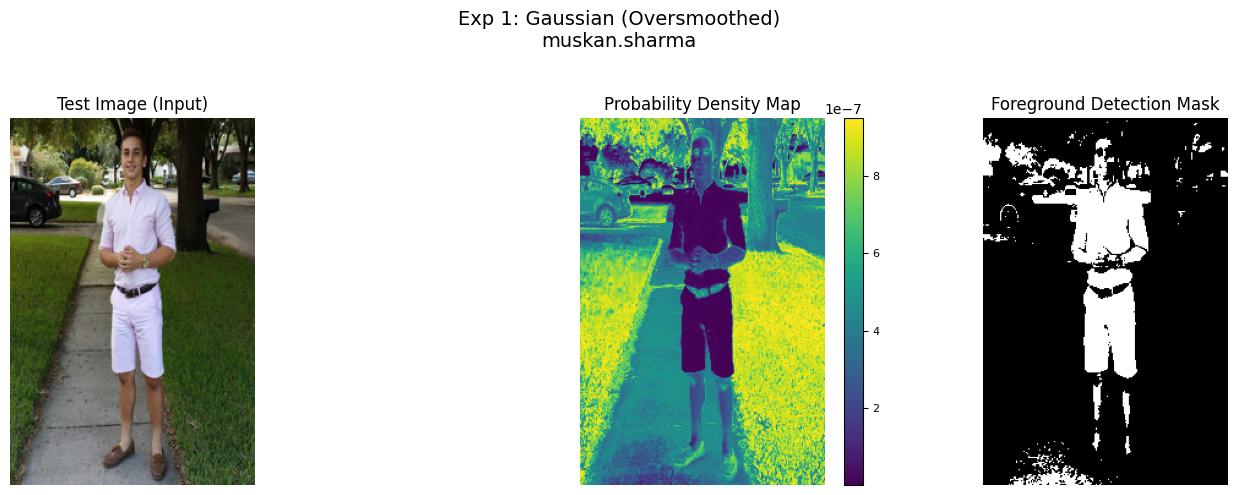


--- Running Exp 2: Gaussian (Optimal) ---
Adaptive Threshold used: 0.000001
Experiment finished (gaussian, h=15.0). Prediction Time: 5.83 seconds.


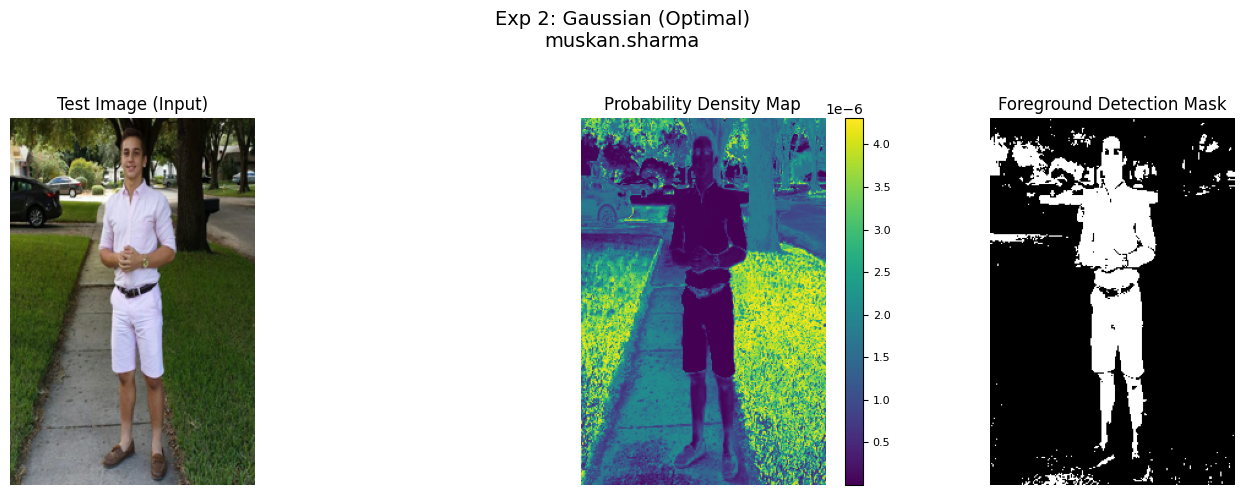


--- Running Exp 3: Gaussian (Undersmoothed) ---
Adaptive Threshold used: 0.000000
Experiment finished (gaussian, h=5.0). Prediction Time: 6.19 seconds.


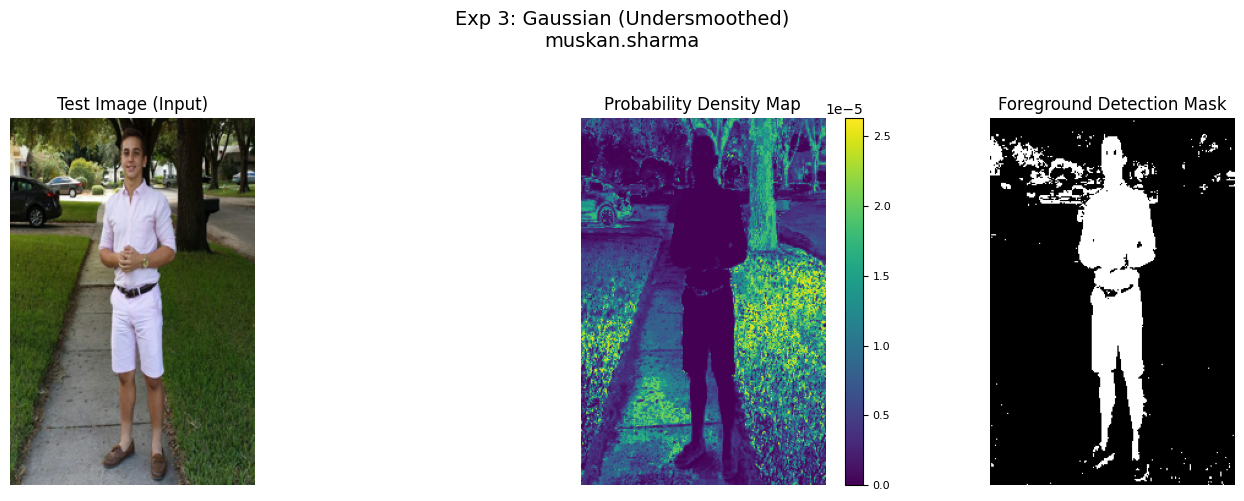


--- Running Exp 4: Triangular (Oversmoothed) ---
Adaptive Threshold used: 0.000001
Experiment finished (triangular, h=30.0). Prediction Time: 6.43 seconds.


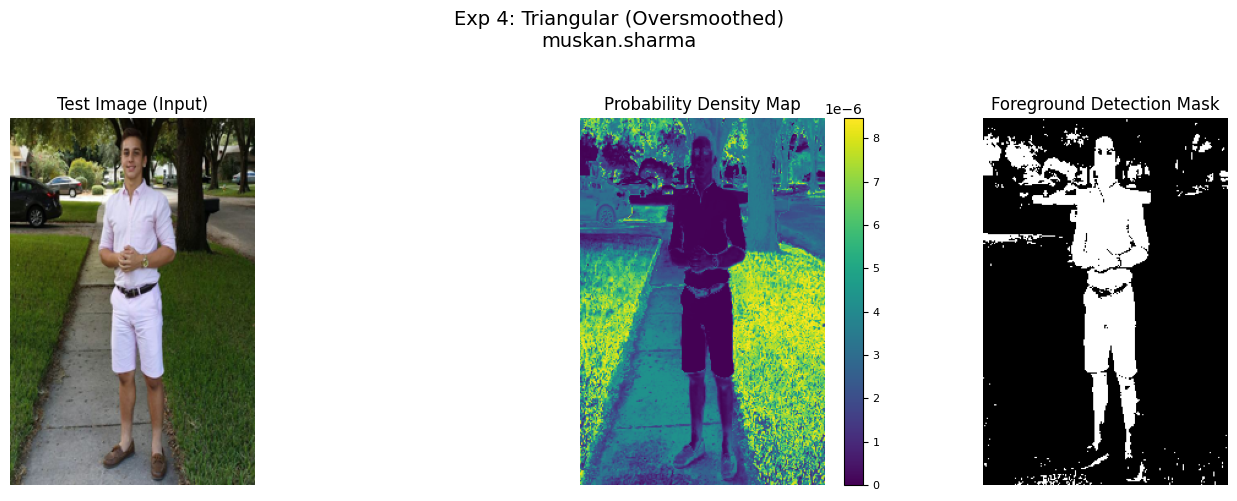


--- Running Exp 5: Triangular (Optimal) ---
Adaptive Threshold used: 0.000001
Experiment finished (triangular, h=15.0). Prediction Time: 6.51 seconds.


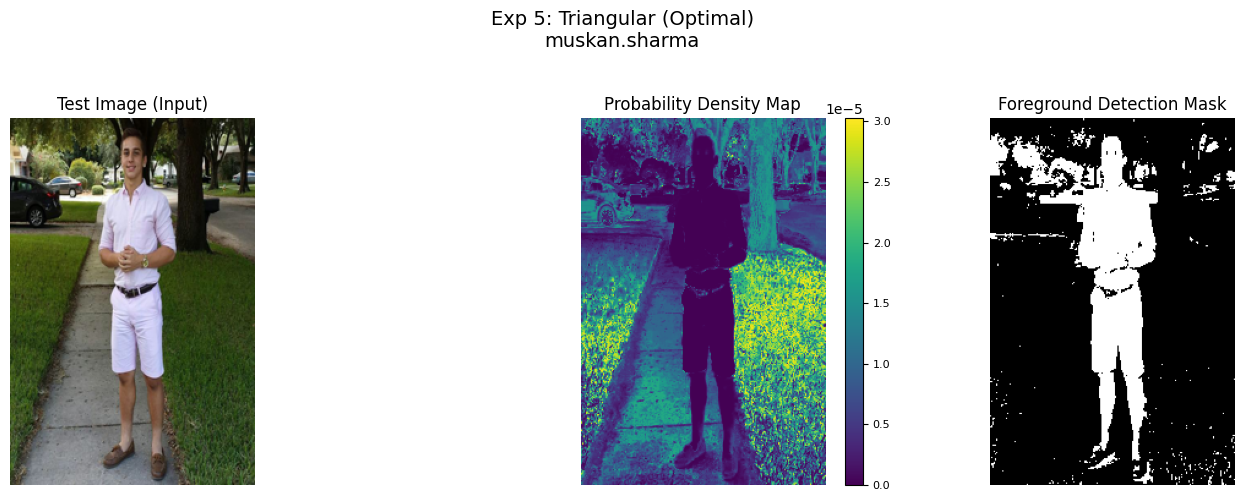


--- Running Exp 6: Uniform (Oversmoothed) ---
Adaptive Threshold used: 0.000003
Experiment finished (uniform, h=30.0). Prediction Time: 7.08 seconds.


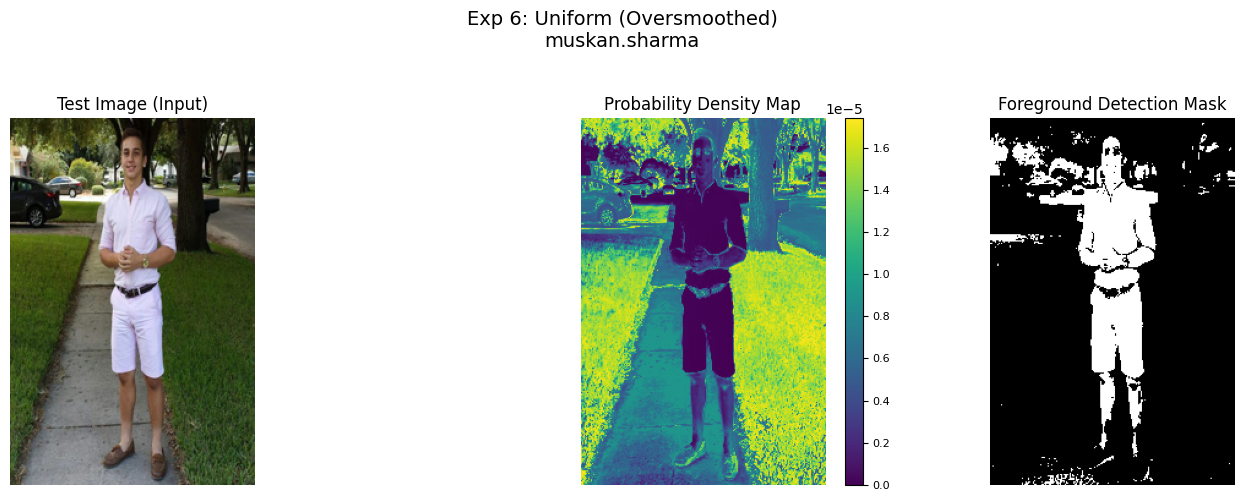


--- Running Exp 7: Uniform (Optimal) ---
Adaptive Threshold used: 0.000006
Experiment finished (uniform, h=15.0). Prediction Time: 7.58 seconds.


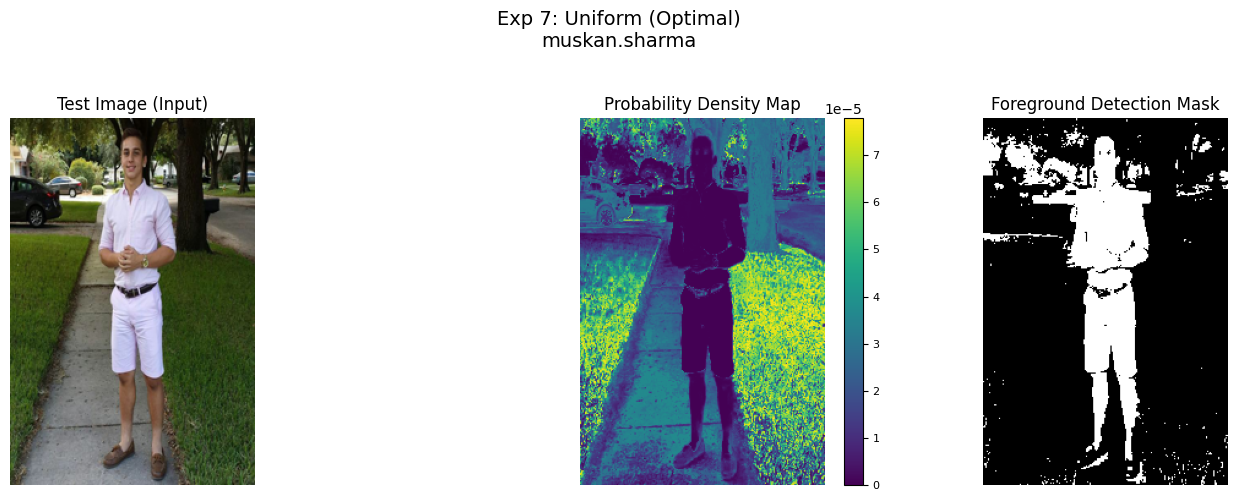

In [ ]:
THRESHOLD = 1e-4 

EXPERIMENT_SETTINGS = {
        "Exp 1: Gaussian (Oversmoothed)": {
            "kernel": 'gaussian', 
            "bandwidth": 30.0, 
            "threshold": THRESHOLD
        },
        "Exp 2: Gaussian (Moderate)": {
            "kernel": 'gaussian', 
            "bandwidth": 15.0, 
            "threshold": THRESHOLD
        },
        "Exp 3: Gaussian (Undersmoothed)": {
            "kernel": 'gaussian', 
            "bandwidth": 5.0, 
            "threshold": THRESHOLD
        },
        "Exp 4: Triangular (Oversmoothed)": {
            "kernel": 'triangular', 
            "bandwidth": 30.0, 
            "threshold": THRESHOLD
        },
        "Exp 5: Triangular (Moderate)": {
            "kernel": 'triangular', 
            "bandwidth": 15.0, 
            "threshold": THRESHOLD
        },
        "Exp 6: Uniform (Oversmoothed)": {
            "kernel": 'uniform', 
            "bandwidth": 30.0, 
            "threshold": THRESHOLD
        },
        "Exp 7: Uniform (Moderate)": {
            "kernel": 'uniform', 
            "bandwidth": 15.0, 
            "threshold": THRESHOLD
        },
    }

for title, params in EXPERIMENT_SETTINGS.items():
    print(f"\n--- Running {title} ---")
    
    mask, density = run_experiment(bg_features, test_features, 
                                    kernel=params["kernel"], bandwidth=params["bandwidth"], threshold=None)
    visualize_results(test_array, mask, density, title)

* Gaussian Kernel: The Gaussian kernel provides the smoothest and most natural density estimate among the tested kernels (Gaussian, Triangular, Uniform). It has infinite support, meaning it assigns some non-zero probability to every pixel, which is beneficial for handling minor variations, noise, or slight lighting shifts in the real-world background data. This prevents noisy background pixels from being spuriously classified as foreground.

* Optimal Bandwidth ($h=15.0$): This value is chosen relative to the 0-255 scale of the RGB features.
    * Low Bandwidth (e.g., $h=5$): Leads to under-smoothing (overfitting). The model becomes too specific to the exact colors present in the $10\%$ sampled background data. This causes noise or small variations in the test image background to be classified as foreground.
    * High Bandwidth (e.g., $h=30$): Leads to over-smoothing. The density estimate is too diffuse. The high probability of the background "bleeds" into the distinct color space of the foreground object, resulting in an incomplete or broken foreground mask.
    * $h=15.0$ effectively balances these trade-offs, providing a stable, generalized background density model while maintaining enough sensitivity to isolate the distinct color features of the foreign (foreground) object.

* Adaptive Threshold: Since probability density values can vary wildly based on bandwidth and feature count, a fixed threshold might be too high. Using adaptive threshold (mean - std) ensures that the threshold is in the range of the predicted density values and makes the foreground prediction more effecient.
